# NOTEBOOK PARA PRONOSTICAR SEMANA DE TRADING

In [9]:
import pandas as pd # sirve para trabajar con datos en forma de tablas
# importar scikit-learn
from sklearn.model_selection import train_test_split # sirve para dividir los datos en entrenamiento y prueba
from sklearn.linear_model import LinearRegression # sirve para crear un modelo de regresion lineal
import numpy as np # sirve para trabajar con arrays y matrices
# graficos dinamicos
import plotly.express as px # sirve para graficos dinamicos
import matplotlib.pyplot as plt # sirve para graficos estaticos
import seaborn as sns # sirve para graficos estadisticos
import matplotlib.dates as mdates
import warnings # sirve para manejar las advertencias
import yfinance as yf # sirve para obtener datos financieros
# Trabajar con fechas
import datetime # sirve para trabajar con fechas
warnings.filterwarnings('ignore') # ignora las advertencias

In [10]:
# configurar API de Yahoo Finance para obtener datos de acciones
def get_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    return stock_data

# cargar datos de acciones
# sIMBOLO DEL ORO
ticker = 'GC=F' # simbolo del oro en Yahoo Finance

# fecha de inicio (ultimos 6 meses)
start_date = (datetime.date.today() - datetime.timedelta(days=180)).strftime('%Y-%m-%d') # fecha de inicio hace 6 meses

# A hoy es la fecha de fin
end_date = datetime.date.today().strftime('%Y-%m-%d')
stock_data = get_stock_data(ticker, start_date, end_date)
# mostrar las primeras filas de los datos
print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2025-11-18  4061.300049  4063.399902  4035.600098  4037.399902   1375
2025-11-19  4077.699951  4122.700195  4072.000000  4086.100098    486
2025-11-20  4056.500000  4090.399902  4040.199951  4045.000000    202
2025-11-21  4076.699951  4085.199951  4031.800049  4031.800049    171
2025-11-24  4091.899902  4091.899902  4060.500000  4060.500000    591


In [11]:
# preparar los datos para el modelo de regresion lineal
# conservar la columna `Date` en formato datetime para graficar
stock_data['Date'] = pd.to_datetime(stock_data.index) # agregar la columna de fecha (datetime)
# crear una columna auxiliar con la fecha en formato ordinal para el modelo
stock_data['DateOrdinal'] = stock_data['Date'].map(datetime.datetime.toordinal)
# convertir la columna ordinal a la variable independiente para el modelo
X = stock_data['DateOrdinal'].values.reshape(-1, 1) # variable independiente (fecha ordinal)
y = stock_data['Close'].values # variable dependiente (precio de cierre)
# dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# crear el modelo de regresion lineal
model = LinearRegression()
# entrenar el modelo
model.fit(X_train, y_train)
# hacer predicciones con el modelo
y_pred = model.predict(X_test)

In [12]:
# evaluar el modelo
from sklearn.metrics import mean_squared_error, r2_score # importar metricas de evaluacion

mse = mean_squared_error(y_test, y_pred) # calcular el error cuadratico medio
r2 = r2_score(y_test, y_pred) # calcular el coeficiente de determinacion
print(f'Mean Squared Error: {mse}') # imprimir el error cuadratico medio
print(f'R^2 Score: {r2}') # imprimir el coeficiente de determinacion

Mean Squared Error: 99632.2368886623
R^2 Score: 0.2151525343711409


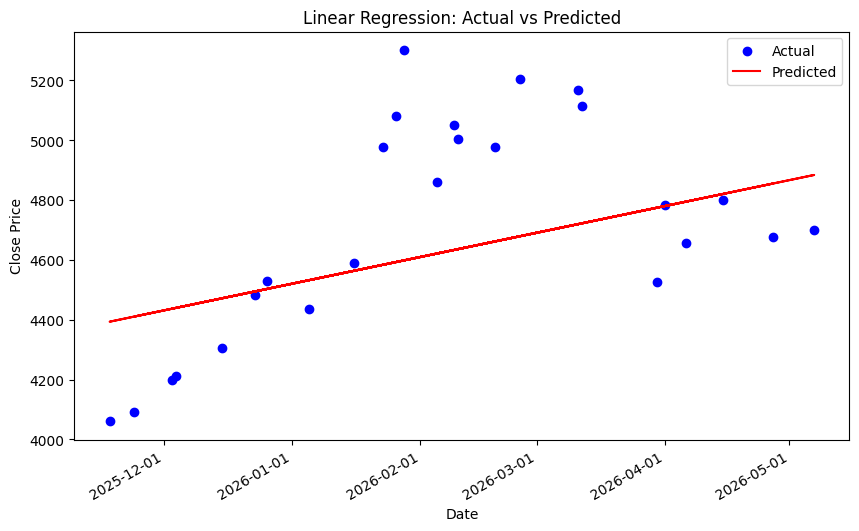

In [13]:
# graficar los resultados (convertir X_test de ordinal a datetime para mostrar fechas)
X_test_dates = [datetime.datetime.fromordinal(int(d)) for d in X_test.flatten()]
plt.figure(figsize=(10, 6)) # configurar el tamaño de la figura
plt.scatter(X_test_dates, y_test, color='blue', label='Actual') # graficar los datos reales
plt.plot(X_test_dates, y_pred, color='red', label='Predicted') # graficar las predicciones
plt.xlabel('Date') # etiqueta del eje x
plt.ylabel('Close Price') # etiqueta del eje y
plt.title('Linear Regression: Actual vs Predicted') # titulo del grafico
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.legend() # mostrar la leyenda
plt.show() # mostrar el grafico

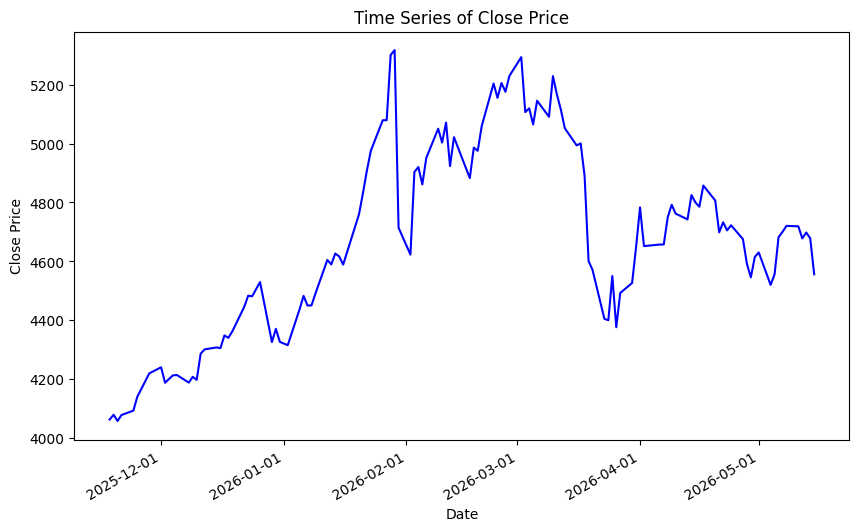

In [14]:
# graficar la serie temporal de los precios de cierre
plt.figure(figsize=(10, 6)) # configurar el tamaño de la figura
plt.plot(stock_data['Date'], stock_data['Close'], color='blue') # graficar la serie temporal
plt.xlabel('Date') # etiqueta del eje x
plt.ylabel('Close Price') # etiqueta del eje y
plt.title('Time Series of Close Price') # titulo del grafico
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.show() # mostrar el grafico

In [15]:
# Pronosticar con estimación de frecuencias e intervalos de confianza
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
# Crear el modelo de regresión lineal
model = LinearRegression()
# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)
# Hacer predicciones con el modelo
y_pred = model.predict(X_test)
# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred) # calcular el error cuadratico medio
r2 = r2_score(y_test, y_pred) # calcular el coeficiente de determinacion
print(f'Mean Squared Error: {mse}') # imprimir el error cuadratico medio
print(f'R^2 Score: {r2}') # imprimir el coeficiente de determinacion

Mean Squared Error: 99632.2368886623
R^2 Score: 0.2151525343711409


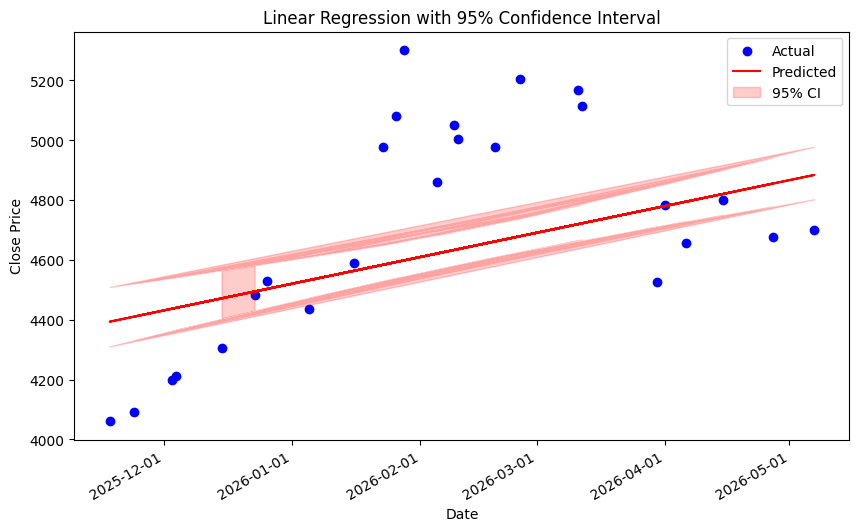

In [16]:
# Pronosticar los proximos 7 días con preiodicidad en minutos por día de semana
n_bootstraps = 1000  # número de muestras bootstrap
bootstrap_preds = []  # lista para almacenar las predicciones bootstrap
for i in range(n_bootstraps):
    # Crear una muestra bootstrap de los datos de entrenamiento
    X_train_bootstrap, y_train_bootstrap = resample(X_train, y_train, random_state=i)
    # Entrenar el modelo con la muestra bootstrap
    model.fit(X_train_bootstrap, y_train_bootstrap)
    # Hacer predicciones con el modelo entrenado en la muestra bootstrap
    y_pred_bootstrap = model.predict(X_test)
    bootstrap_preds.append(y_pred_bootstrap)  # almacenar las predicciones bootstrap
# Convertir la lista de predicciones bootstrap a un array numpy
bootstrap_preds = np.array(bootstrap_preds)
# Calcular el intervalo de confianza al 95% para cada predicción
lower_bound = np.percentile(bootstrap_preds, 2.5, axis=0)  # límite inferior
upper_bound = np.percentile(bootstrap_preds, 97.5, axis=0)  # límite superior
# Graficar las predicciones con intervalos de confianza
X_test_dates = [datetime.datetime.fromordinal(int(d)) for d in X_test.flatten()]  # convertir a datetime
# convertir a números de fecha (matplotlib) para asegurar compatibilidad con fill_between
X_test_num = mdates.date2num(X_test_dates)
# Asegurar que los bounds y predicciones sean arrays 1D de la misma longitud
lower_bound = np.asarray(lower_bound).ravel()
upper_bound = np.asarray(upper_bound).ravel()
y_pred = np.asarray(y_pred).ravel()
y_test_arr = np.asarray(y_test).ravel()
plt.figure(figsize=(10, 6))  # tamaño de la figura
plt.scatter(X_test_num, y_test_arr, color='blue', label='Actual')  # datos reales
plt.plot(X_test_num, y_pred, color='red', label='Predicted')  # predicciones
plt.fill_between(X_test_num, lower_bound, upper_bound, color='red', alpha=0.2, label='95% CI')  # intervalo de confianza
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Linear Regression with 95% Confidence Interval')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.legend()
plt.show()
